# Matching

The purpose of this file is to do one set of matching: **treatment matching**, to match those who graduated from the program against those that did not graduate from the program. 

We will match to examine the following:

-Graduation effect for **earnings** (income)

-Graduation effect for **employment**

-Graduation effect for **criminal justice interaction** (as measured by arrests)

-Graduation effect for **recidivism** (as measured by offenses)

This will be followed (in future analysis) by intent to treat matching of TIP participants with similar non-participants, which we expect will be particularly relevant for criminal justice and recidivism outcomes. 


# Preparation

In [1]:
#Import necessary packages

import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import tqdm
##!pip install linearmodels
from linearmodels import PanelOLS
import statsmodels.api as sm
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.cov_struct import Exchangeable

In [2]:
#Import necessary files

#Student datafile, data up to December 2025 
tip_clean = pd.read_csv(r'TIP_clean.csv', parse_dates=['CreatedDate','DoB', 'Interviewed Only Date', 'InterviewedDate','StartDate','EndDate'])

#Demographic datafile, data up to December 2024
tip_demos = pd.read_csv(r'tip_cohort_demographics_rg.csv')

#Sentencing datafile, data up to December 2024
tip_sentencing = pd.read_csv(r'convictions_matched_to_tip_final.csv', parse_dates = ['DOB', 'GraduatedDate', 'InterviewedDate', 'StartDate','EndDate', 'DOF', 'DOS'])

#Arrests datafile, data up to December 2024
tip_arrests = pd.read_csv(r'arrest_data.csv', parse_dates = ['CaseFiledDate', 'ArrestDate', 'DefendantDOB', 'OffenseDate','OffenseDispositionDate','CaseDispositionDate','InterviewedDate','Orientation Date', 'GraduatedDate', 'CreatedDate','StartDate','EndDate'])


#Earnings datafile, data up to December 2024
tip_earnings = pd.read_csv(r'tip_cohort_uiearnings.csv')

#Deflation information to deflate earnings data
df_inflation = pd.read_csv(r'inflation_data.csv')



C:\Users\13429\AppData\Local\Temp\ipykernel_22080\2157123057.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tip_arrests = pd.read_csv(r'arrest_data.csv', parse_dates = ['CaseFiledDate', 'ArrestDate', 'DefendantDOB', 'OffenseDate','OffenseDispositionDate','CaseDispositionDate','InterviewedDate','Orientation Date', 'GraduatedDate', 'CreatedDate','StartDate','EndDate'])
C:\Users\13429\AppData\Local\Temp\ipykernel_22080\2157123057.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tip_arrests = pd.read_csv(r'arrest_data.csv', parse_dates = ['CaseFiledDate', 'ArrestDate', 'DefendantDOB', 'OffenseDate','OffenseDispositionDate','CaseDispositionDate','InterviewedDate','Orientation Date', 'GraduatedDate', 'Creat

In [3]:
#Clean student datafile column names

all_tip_students = tip_clean.rename(columns={
    'participant_id' : 'tip_id',
    'DoB' : 'DOB',
    'Status' : 'tip_status',
})

#Define statuses as "Graduated" or "Non Graduated" - for the purposes of this matched analysis, we do not care about individuals who do not fall into these statuses

def status(row):
    ts = str(row['tip_status'])
    if "Graduate" in ts:
        return 'Graduated'
    #TIP does not consider individuals who did not finish orientation to be participants, so all DNF status EXCEPT those that are DNF orientation are our "Non Graduated" pool
    elif ("DNF" in ts) and ("Orientation" not in ts):
        return 'Non Graduated'
    else:
        return 'None'

all_tip_students['Status'] = all_tip_students.apply(status, axis=1)
all_tip_students.Status.value_counts()

Status
None             1281
Graduated         893
Non Graduated     549
Name: count, dtype: int64

In [4]:
all_tip_students.columns

Index(['tip_id', 'CreatedDate', 'DOB', 'tip_status', 'Course', 'StartDate',
       'EndDate', 'InterviewedDate', 'Interviewed Only Date', 'DriversLicense',
       'EndDriversLicense', 'AccessBank', 'EndBank', 'EndComputer',
       'AccessComputer', 'AccessHealthInsurance', 'EndHealthInsurance',
       'AccessInternet', 'EndInternet', 'AccessResume', 'EndResume',
       'License To Thrive', 'Workforce Housing', 'SNAP Assistance',
       'Age_at_start', 'Status'],
      dtype='object')

In [5]:
#Put together our cleaned student data frame (which we will call df_student)

df_student = all_tip_students.copy()

date_cols = ['DOB', 'StartDate', 'EndDate', 'InterviewedDate', 'Interviewed Only Date']
for col in date_cols:
    if col in df_student.columns:
        df_student[col] = pd.to_datetime(df_student[col], errors = 'coerce')

##Add an indicator for cohort based on StartDate
cutoff = pd.Timestamp("2022-01-01")
df_student["cohort_2022"] = np.where(
    df_student["StartDate"].notna(),
    np.where(df_student["StartDate"] >= cutoff, 1, 0),
    np.nan
)

df_student["cohort_2022"] = pd.to_numeric(df_student["cohort_2022"], errors = "coerce")

#Drop anyone with nonsensical ages (under 16)
df_student = df_student[df_student['Age_at_start'] >= 16]

#Add age band based on age at start

def assign_age_band(age):
    if pd.isna(age):
        return np.nan
    elif 18 <= age <= 24:
        return '<=24'
    elif 25 <= age <= 34:
        return '25-34'
    elif age >= 35:
        return '35+'
    else:
        return np.nan

df_student['age_band'] = df_student['Age_at_start'].apply(assign_age_band)

df_student.head()

,tip_id,CreatedDate,DOB,tip_status,Course,StartDate,EndDate,InterviewedDate,Interviewed Only Date,DriversLicense,...,EndInternet,AccessResume,EndResume,License To Thrive,Workforce Housing,SNAP Assistance,Age_at_start,Status,cohort_2022,age_band
0,1,2018-07-11 00:00:00+00:00,1992-08-26,DNF: Dropped Out,Introduction to Masonry,2018-07-12,2018-08-01 00:00:00+00:00,NaT,NaT,No,...,NaN,NaN,NaN,NaN,NaN,NaN,25.840055,Non Graduated,0.0,25-34
1,2,2018-07-11 00:00:00+00:00,1997-01-27,DNF: Asked to Leave,Introduction to Masonry,2018-07-12,NaT,NaT,NaT,No,...,NaN,NaN,NaN,NaN,NaN,NaN,21.424470,Non Graduated,0.0,<=24
2,3,2018-07-11 00:00:00+00:00,1999-05-04,DNF: Asked to Leave,Introduction to Masonry,2018-07-23,NaT,NaT,NaT,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,19.193438,Non Graduated,0.0,<=24
3,4,2018-07-12 00:00:00+00:00,1982-08-15,Graduated-Employed,Introduction to Masonry,2013-08-12,2013-10-16 00:00:00+00:00,NaT,NaT,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,30.950103,Graduated,0.0,25-34
4,5,2018-07-12 00:00:00+00:00,1988-04-10,Graduated-Employed,Introduction to Masonry,2010-11-29,2011-02-04 00:00:00+00:00,NaT,NaT,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,22.605605,Graduated,0.0,<=24


In [6]:
#Merge with demographics

tip_demos['tip_id'] = pd.to_numeric(tip_demos['tip_id'], errors='coerce')
df_student['tip_id'] = pd.to_numeric(df_student['tip_id'], errors='coerce')

df_student = df_student.merge(
    tip_demos,
    on = 'tip_id',
    how = 'left'
)

In [7]:
#Prepare sentencing data

tip_sentencing['DOB'] = pd.to_datetime(tip_sentencing['DOB'], errors='coerce').dt.tz_localize(None)
tip_sentencing['StartDate'] = pd.to_datetime(tip_sentencing['StartDate'], errors='coerce').dt.tz_localize(None)
tip_sentencing['EndDate'] = pd.to_datetime(tip_sentencing['EndDate'], errors='coerce').dt.tz_localize(None)
tip_sentencing['tip_id'] = pd.to_numeric(tip_sentencing['tip_id'], errors='coerce')
tip_sentencing['age_at_sentencing'] = (
    (tip_sentencing['DOS'] - tip_sentencing['DOB'])).dt.days // 365

# merge student StartDate for consistent baseline cutoff
tip_sentencing = tip_sentencing.merge(
    df_student[['tip_id', 'StartDate']],
    on='tip_id',
    how='left',
    suffixes=('', '_student')
)

if 'StartDate_student' in tip_sentencing.columns:
    tip_sentencing['StartDate'] = tip_sentencing['StartDate_student'].combine_first(tip_sentencing['StartDate'])
    tip_sentencing = tip_sentencing.drop(columns=['StartDate_student'])

# before TIP start
sent_before = tip_sentencing[
    tip_sentencing['DOS'].notna() &
    tip_sentencing['StartDate'].notna() &
    (tip_sentencing['DOS'] < tip_sentencing['StartDate'])
].copy()

sent_summary = sent_before.groupby('tip_id').agg(
    num_sentences_before_start=('DOS', 'count'),
    any_sentence_before_start=('DOS', lambda x: 1 if len(x) > 0 else 0),
    min_age_at_sentencing_before_start=('age_at_sentencing', 'min'),
    max_ogs_before_start=('OGS', 'max'),
    any_high_ogs_before_start=('OGS', lambda x: 1 if (x > 5).any() else 0)
).reset_index()

#create wide table
sent_wide= tip_sentencing[['tip_id', 'age_at_sentencing']].drop_duplicates()
sent_wide['value'] = 1
sent_wide = sent_wide.pivot(index='tip_id', columns='age_at_sentencing', values='value').fillna(0)
sent_wide = sent_wide.reset_index().rename_axis(None, axis=1)

drop_cols = [np.nan]
for column in sent_wide.columns[2:]:
    column = int(column)
    new_col = f'{column}_sentencing_age'
    sent_wide[new_col] = sent_wide[column]
    drop_cols.append(column)

sent_wide = sent_wide.drop(columns=drop_cols)

#create a high OGS table
high_tip_ogs = tip_sentencing[tip_sentencing['OGS'] > 5]
high_tip_ogs_wide = high_tip_ogs[['tip_id', 'age_at_sentencing']].drop_duplicates().dropna()
high_tip_ogs_wide['value'] = 1
high_tip_ogs_wide = high_tip_ogs_wide.pivot(index='tip_id', columns='age_at_sentencing', values='value').fillna(0)
high_tip_ogs_wide = high_tip_ogs_wide.reset_index().rename_axis(None, axis=1)

drop_cols = []
for column in high_tip_ogs_wide.columns[1:]:
    column = int(column)
    new_col = f'{column}_sentencing_age_high_ogs'
    high_tip_ogs_wide[new_col] = high_tip_ogs_wide[column]
    drop_cols.append(column)

high_tip_ogs_wide = high_tip_ogs_wide.drop(columns=drop_cols)

#Merge both wide tables together
sent_wide = sent_wide.merge(
    high_tip_ogs_wide, 
    on='tip_id', 
    how='left').fillna(0)

sent_wide.head()

,tip_id,16_sentencing_age,17_sentencing_age,18_sentencing_age,19_sentencing_age,20_sentencing_age,21_sentencing_age,22_sentencing_age,23_sentencing_age,24_sentencing_age,...,43_sentencing_age_high_ogs,44_sentencing_age_high_ogs,45_sentencing_age_high_ogs,46_sentencing_age_high_ogs,47_sentencing_age_high_ogs,48_sentencing_age_high_ogs,49_sentencing_age_high_ogs,51_sentencing_age_high_ogs,52_sentencing_age_high_ogs,58_sentencing_age_high_ogs
0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
#Prepare arrests data (similar process to conviction data above)

tip_arrests['tip_id'] = pd.to_numeric(tip_arrests['tip_id'], errors='coerce')

tip_arrests = tip_arrests.merge(
    df_student[['tip_id', 'DOB', 'StartDate']],
    on='tip_id',
    how='left',
    suffixes=('', '_student')
)

if 'StartDate_student' in tip_arrests.columns:
    tip_arrests['StartDate'] = tip_arrests['StartDate_student'].combine_first(tip_arrests['StartDate'])
    tip_arrests = tip_arrests.drop(columns=['StartDate_student'])

tip_arrests['age_at_arrest'] = (
    (tip_arrests['ArrestDate'] - tip_arrests['DOB']).dt.days // 365
)

arrests_before = tip_arrests[
    tip_arrests['ArrestDate'].notna() &
    tip_arrests['StartDate'].notna() &
    (tip_arrests['ArrestDate'] < tip_arrests['StartDate'])
].copy()

arrest_summary = arrests_before.groupby('tip_id').agg(
    num_arrests_before_start=('ArrestDate', 'count'),
    any_arrest_before_start=('ArrestDate', lambda x: 1 if len(x) > 0 else 0),
    min_age_at_arrest_before_start=('age_at_arrest', 'min')
).reset_index()

#pivot wider
arrests_wide = tip_arrests[['tip_id', 'age_at_arrest']].drop_duplicates()
arrests_wide['value'] = 1
arrests_wide = arrests_wide.pivot(index='tip_id', columns='age_at_arrest', values='value').fillna(0).reset_index().rename_axis(None, axis=1)

drop_cols = [np.nan]
for column in arrests_wide.columns[2:]:
    column = int(column)
    new_col = f'{column}_arrest_age'
    arrests_wide[new_col] = arrests_wide[column]
    drop_cols.append(column)

arrests_wide = arrests_wide.drop(columns=drop_cols)

#add YearsSinceTIP to long df for later outcome analysis
tip_arrests['YearsSinceTIP'] = (tip_arrests['ArrestDate'] - tip_arrests['StartDate']).dt.days / 365


In [9]:
#Prepare earnings data

# process quarter to datetime
q_str = tip_earnings["quarter"].astype(str).str.strip()

tip_earnings["year"] = q_str.str[:4].astype(int)
tip_earnings["qnum"] = q_str.str[-1].astype(int)  # 1-4

# map to calendar quarter end month/day
# Q1 -> 03/31
# Q2 -> 06/30
# Q3 -> 09/30
# Q4 -> 12/31 

#Nikki: This was slightly different in your code. I matched it to what we did for the midterm analysis.
month_map = {1: 3, 2: 6, 3: 9, 4: 12}
day_map   = {1: 31, 2: 30, 3: 30, 4: 31}

tip_earnings["cal_end_year"] = tip_earnings["year"]
tip_earnings["cal_end_month"] = tip_earnings["qnum"].map(month_map)
tip_earnings["cal_end_day"] = tip_earnings["qnum"].map(day_map)

tip_earnings["year_quarter_dt"] = pd.to_datetime(
    dict(
        year=tip_earnings["cal_end_year"],
        month=tip_earnings["cal_end_month"],
        day=tip_earnings["cal_end_day"],
    ),
    errors="coerce",
)

tip_earnings["year_month"] = tip_earnings["year_quarter_dt"].dt.to_period("M")
tip_earnings.drop(columns=["Unnamed: 0", "qnum", "cal_end_year", "cal_end_month", "cal_end_day"], errors="ignore", inplace=True)

In [10]:
df_inflation.columns

Index(['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep',
       'Oct', 'Nov', 'Dec', 'HALF1', 'HALF2'],
      dtype='object')

In [11]:
#Adjust earnings data for inflation (deflate the data)
df_inflation.drop(columns=['HALF1', 'HALF2'], inplace=True)
df_inflation = df_inflation.melt(id_vars='Year', var_name='Month', value_name='CPI')

month_map = {'Jan':'01','Feb':'02','Mar':'03','Apr':'04','May':'05','Jun':'06',
             'Jul':'07','Aug':'08','Sep':'09','Oct':'10','Nov':'11','Dec':'12'}
df_inflation["year_month"] = (
    df_inflation["Year"].astype(str) + "-" + df_inflation["Month"].map(month_map)
)
# sort by date to ensure that the latest CPI value is at the end of the DataFrame
df_inflation = df_inflation.sort_values("year_month").reset_index(drop=True)
latest_cpi = df_inflation.loc[df_inflation["year_month"] == "2025-12", "CPI"].iloc[0]

tip_earnings["year_month"] = tip_earnings["year_month"].astype(str)

cpi_map = df_inflation.drop_duplicates("year_month").set_index("year_month")["CPI"]
tip_earnings["CPI"] = tip_earnings["year_month"].map(cpi_map)

tip_earnings["adjusted_earnings"] = tip_earnings["earnings"] * (latest_cpi / tip_earnings["CPI"])

In [12]:
tip_earnings.head()

,tip_id,quarter,employer_legal_name,earnings,naics_code,naics_sector_2017,naics_subsector_2017,naics_industry_2017,naics_sector_2022,naics_subsector_2022,naics_industry_2022,year,year_quarter_dt,year_month,CPI,adjusted_earnings
0,655,20182,LEHIGH VALLEY RESTAURANT GROUP INC,1434,722511.0,Accommodation and food services,Food services and drinking places,Full-Service Restaurants,Accommodation and Food Services,Food Services and Drinking Places,Full-Service Restaurants,2018,2018-06-30,2018-06,251.989,1844.102068
1,556,20174,COST COMPANY,3147,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2017,2017-12-31,2017-12,246.524,4136.708548
2,556,20174,FRANCO,4654,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2017,2017-12-31,2017-12,246.524,6117.649056
3,556,20181,COST COMPANY,1908,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2018,2018-03-31,2018-03,249.554,2477.600167
4,556,20181,FRANCO,7165,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2018,2018-03-31,2018-03,249.554,9303.985951


In [13]:
#Calculate earnings 1 year and 2 years pre-TIP for match

tip_earnings = pd.merge(
    tip_earnings,
    df_student[['tip_id', 'StartDate']].drop_duplicates(),
    on='tip_id',
    how = 'left'
)
    
# keep non-missing earnings, but DO NOT drop zeros
tip_earnings = tip_earnings.dropna(subset=['earnings', 'StartDate']).copy()

# time distance relative to TIP start
tip_earnings['quarters_from_start'] = (
    (tip_earnings['year_quarter_dt'].dt.year - tip_earnings['StartDate'].dt.year) * 4
    + (tip_earnings['year_quarter_dt'].dt.quarter - tip_earnings['StartDate'].dt.quarter)
)

tip_earnings.head()

#aggregate 1-year pre-TIP earnings (quarters -1 through -4)
earnings_1yr_pre = (
    tip_earnings[tip_earnings['quarters_from_start'].between(-4, -1)]
    .groupby('tip_id')['adjusted_earnings']
    .sum()
    .reset_index()
    .rename(columns={'adjusted_earnings': 'earnings_1yr_preTIP'})
)
##Consider cumulative - double check this isn't what the previous team was doing
#2-year pre-TIP earnings (quarters -5 through -8)
earnings_2yr_pre = (
    tip_earnings[tip_earnings['quarters_from_start'].between(-8, -5)]
    .groupby('tip_id')['adjusted_earnings']
    .sum()
    .reset_index()
    .rename(columns={'adjusted_earnings': 'earnings_2yr_preTIP'})
)

earnings_2yr_pre.head()

,tip_id,earnings_2yr_preTIP
0,1,410.102835
1,2,8049.772420
2,29,35597.891193
3,210,3436.631229
4,216,1467.860077


In [14]:
#Summarize employment immediately pre-TIP using earnings data (just checks for existence of any earnings in the year immediately prior to TIP
job_right_before = (
    tip_earnings[tip_earnings['quarters_from_start'].between(-4, -1)]  #Nikki I adjusted this to quarters 1-4 instead of just quarter 1
    .groupby('tip_id')['adjusted_earnings']
    .apply(lambda x: 1 if (x > 0).any() else 0)
    .reset_index(name='job_right_before_tip')
)

In [15]:
#Calculate age at point of each earnings record and pivot wide

tip_dob = df_student[['tip_id', 'DOB']].drop_duplicates()
tip_earnings = pd.merge(
    tip_earnings,
    tip_dob,
    on='tip_id',
    how='left'
)

tip_earnings['age'] = (tip_earnings['year_quarter_dt']-tip_earnings['DOB']).dt.days//365

#pivot wider
earnings_wide = tip_earnings[['tip_id','age', 'adjusted_earnings']].copy()
earnings_wide = earnings_wide.groupby(['tip_id', 'age'])['adjusted_earnings'].sum().reset_index()
earnings_wide = earnings_wide.pivot(index='tip_id', columns='age', values='adjusted_earnings').fillna(0)
earnings_wide = earnings_wide.reset_index().rename_axis(None, axis=1)
earnings_wide.rename(columns={col: f'{col}_earnings' for col in earnings_wide.columns[1:]}, inplace=True)

##Note: Some records are for individuals that were apparently 10-13 at the time of the earnings record. Maybe a mismatch. For safety we've removed nonsensical ages from the dataframe based on age at start.
earnings_wide.head()

#add YearsSinceTIP to long df for later outcome analysis
tip_earnings['YearsSinceTIP'] = (tip_earnings['year_quarter_dt'] - tip_earnings['StartDate']).dt.days / 365

In [16]:
tip_earnings[tip_earnings['age'] < 16][['tip_id', 'DOB', 'year_quarter_dt', 'adjusted_earnings', 'age']].head()

,tip_id,DOB,year_quarter_dt,adjusted_earnings,age
39,1292,2002-02-19,2017-12-31,1263.227491,15
40,1292,2002-02-19,2017-12-31,946.434749,15
50,1641,2002-10-11,2017-12-31,10437.072090,15
51,1641,2002-10-11,2017-12-31,1635.228927,15
52,2246,2002-03-17,2017-12-31,8294.448979,15


In [17]:
#Create one wide dataframe

all_tip_data = pd.merge(
    df_student,
    sent_wide.fillna(0),
    on = 'tip_id',
    how = 'left'
)

all_tip_data = pd.merge(
    all_tip_data,
    arrests_wide.fillna(0),
    on = 'tip_id',
    how = 'left'
)

all_tip_data = pd.merge(
    all_tip_data,
    earnings_wide.fillna(0),
    on = 'tip_id',
    how = 'left'
)


In [18]:
#fill remaining NAs (for unmatched IDs) with 0s
all_tip_data[sent_wide.columns] = all_tip_data[sent_wide.columns].fillna(0)
all_tip_data[arrests_wide.columns] = all_tip_data[arrests_wide.columns].fillna(0)
all_tip_data[earnings_wide.columns] = all_tip_data[earnings_wide.columns].fillna(0)
all_tip_data[tip_demos.columns] = all_tip_data[tip_demos.columns].fillna(0)

all_tip_data.head()

,tip_id,CreatedDate,DOB,tip_status,Course,StartDate,EndDate,InterviewedDate,Interviewed Only Date,DriversLicense,...,56_earnings,57_earnings,58_earnings,59_earnings,60_earnings,61_earnings,62_earnings,63_earnings,64_earnings,65_earnings
0,1,2018-07-11 00:00:00+00:00,1992-08-26,DNF: Dropped Out,Introduction to Masonry,2018-07-12,2018-08-01 00:00:00+00:00,NaT,NaT,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,2018-07-11 00:00:00+00:00,1997-01-27,DNF: Asked to Leave,Introduction to Masonry,2018-07-12,NaT,NaT,NaT,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,2018-07-11 00:00:00+00:00,1999-05-04,DNF: Asked to Leave,Introduction to Masonry,2018-07-23,NaT,NaT,NaT,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,2018-07-12 00:00:00+00:00,1982-08-15,Graduated-Employed,Introduction to Masonry,2013-08-12,2013-10-16 00:00:00+00:00,NaT,NaT,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,2018-07-12 00:00:00+00:00,1988-04-10,Graduated-Employed,Introduction to Masonry,2010-11-29,2011-02-04 00:00:00+00:00,NaT,NaT,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
#combine with summary data for matching
all_tip_data = pd.merge(
    all_tip_data,
    sent_summary, 
    on='tip_id', 
    how='left'
)

all_tip_data = pd.merge(
    all_tip_data,
    arrest_summary, 
    on='tip_id', 
    how='left'
)

all_tip_data = pd.merge(
    all_tip_data,
    earnings_1yr_pre, 
    on='tip_id', 
    how='left'
)

all_tip_data = pd.merge(
    all_tip_data,
    earnings_2yr_pre, 
    on='tip_id', 
    how='left'
)

all_tip_data = pd.merge(
    all_tip_data,
    job_right_before, 
    on='tip_id', 
    how='left'
)

tip_fill_zero_cols = [
    'num_sentences_before_start',
    'any_sentence_before_start',
    'max_ogs_before_start',
    'any_high_ogs_before_start',
    'num_arrests_before_start',
    'any_arrest_before_start',
    'earnings_1yr_preTIP',
    'earnings_2yr_preTIP',
    'job_right_before_tip'
]

for col in tip_fill_zero_cols:
    if col in all_tip_data.columns:
        all_tip_data[col] = all_tip_data[col].fillna(0)




In [20]:
print("all_tip_data shape:", all_tip_data.shape)
print("\nTIP missingness summary:")
print(
    all_tip_data[
        [
            'tip_id', 'DOB', 'StartDate', 'Status', 'cohort_2022',
            'Age_at_start', 'age_band', 'gender', 'race', 'census_tract',
            'num_sentences_before_start', 'any_sentence_before_start',
            'max_ogs_before_start', 'any_high_ogs_before_start',
            'num_arrests_before_start', 'any_arrest_before_start',
            'earnings_1yr_preTIP', 'earnings_2yr_preTIP',
            'job_right_before_tip'
        ]
    ].isna().sum()
)

all_tip_data shape: (1801, 228)

TIP missingness summary:
tip_id                          0
DOB                             0
StartDate                       0
Status                          0
cohort_2022                     0
Age_at_start                    0
age_band                      141
gender                          0
race                            0
census_tract                    0
num_sentences_before_start      0
any_sentence_before_start       0
max_ogs_before_start            0
any_high_ogs_before_start       0
num_arrests_before_start        0
any_arrest_before_start         0
earnings_1yr_preTIP             0
earnings_2yr_preTIP             0
job_right_before_tip            0
dtype: int64


# Defining Outcomes

This section constructs the analysis dataset for comparing TIP graduates with non-graduates.
At this stage, we are not yet performing the final matching or regression. Instead, we define the treatment group, assembel baseline covariates measured before TIP start, and create post-TIP outcome variables. 

We define:

-**Treatment group**: Graduated participants

-**Control group**: Non-Graduated participants

We focus on the following outcomes within 1.5 years after TIP start:

-(Y_e): any employment

-(Y_w): total earnings (adjusted)

-(Y_o): any offense

-(Y_a): any arrest

-(Y_c): ANy post-TIP conviction-related offense record

The baseline covariates are measured before TIP start and include demographics, cohort, age band, prior justice involvement, and prior earnings history. These variables will later be used for sample diagnostics, matching, and regression adjustment. 

In [21]:
#Create a graduate/nongrad only file
grad_non_grad = all_tip_data.copy()

grad_non_grad = grad_non_grad[
    grad_non_grad['Status'].isin(['Graduated', 'Non Graduated'])
].copy()

#Apply the study cutoff
grad_non_grad = grad_non_grad[
    grad_non_grad['StartDate'] < pd.Timestamp('2024-06-01')
].copy()

#Define treatment
grad_non_grad['treatment'] = np.where(
    grad_non_grad['Status'] == 'Graduated',
    1,
    0
)

#Keep plausible adult ages
grad_non_grad = grad_non_grad[
    grad_non_grad['Age_at_start'].notna() &
    (grad_non_grad['Age_at_start'] > 15)
].copy()

# Clean demographic display values
grad_non_grad['race'] = grad_non_grad['race'].fillna('Unknown').replace(0, 'Unknown')
grad_non_grad['gender'] = grad_non_grad['gender'].fillna('Unknown').replace(0, 'Unknown')

grad_non_grad['census_tract'] = grad_non_grad['census_tract'].where(
    grad_non_grad['census_tract'].notna(),
    'Unknown'
)

grad_non_grad['census_tract'] = grad_non_grad['census_tract'].apply(
    lambda x: 'Unknown' if x == 'Unknown' else str(int(x))
)

In [22]:
#Calculate outcomes for each participant
def employment_outcome(row):
    tip_id = row['tip_id']
    return tip_earnings[
        (tip_earnings['tip_id'] == tip_id) &
        (tip_earnings['adjusted_earnings'] != 0) &
        (tip_earnings['YearsSinceTIP'] > 0) &
        (tip_earnings['YearsSinceTIP'] < 1.5)
    ].shape[0] > 0

def employment_outcome_earnings(row):
    tip_id = row['tip_id']
    return tip_earnings[
        (tip_earnings['tip_id'] == tip_id) &
        (tip_earnings['adjusted_earnings'] != 0) &
        (tip_earnings['YearsSinceTIP'] > 0) &
        (tip_earnings['YearsSinceTIP'] < 1.5)
    ]['adjusted_earnings'].sum()

def offense_outcome(row):
    tip_id = row['tip_id']
    return tip_sentencing[
        (tip_sentencing['tip_id'] == tip_id) &
        (tip_sentencing['YearsSinceTIP'] > 0) &
        (tip_sentencing['YearsSinceTIP'] < 1.5)
    ].shape[0] > 0

def arrest_outcome(row):
    tip_id = row['tip_id']
    return tip_arrests[
        (tip_arrests['tip_id'] == tip_id) &
        (tip_arrests['YearsSinceTIP'] > 0) &
        (tip_arrests['YearsSinceTIP'] < 1.5)
    ].shape[0] > 0

def year_start(row):
    tip_id = row['tip_id']
    return df_student[df_student['tip_id'] == tip_id]['StartDate'].dt.year.values[0]



grad_non_grad['employment_outcome'] = grad_non_grad.apply(employment_outcome, axis=1).astype(int)
grad_non_grad['earnings_outcome'] = grad_non_grad.apply(employment_outcome_earnings, axis=1)
grad_non_grad['offense_outcome'] = grad_non_grad.apply(offense_outcome, axis=1).astype(int)
grad_non_grad['arrest_outcome'] = grad_non_grad.apply(arrest_outcome, axis=1).astype(int)

grad_non_grad['year_TIP'] = grad_non_grad.apply(year_start, axis=1)



In [23]:
grad_non_grad[['employment_outcome', 'earnings_outcome', 'offense_outcome', 'arrest_outcome']].isna().sum()

employment_outcome    0
earnings_outcome      0
offense_outcome       0
arrest_outcome        0
dtype: int64

In [24]:
print("grad_non_grad shape:", grad_non_grad.shape)
print("\nStatus counts:")
print(grad_non_grad['Status'].value_counts(dropna=False))

print("\nTreatment counts:")
print(grad_non_grad['treatment'].value_counts(dropna=False))

print("\nCohort counts:")
print(grad_non_grad['cohort_2022'].value_counts(dropna=False))

print("\nAge band counts:")
print(grad_non_grad['age_band'].value_counts(dropna=False))

print("\nOutcome means:")
print(
    grad_non_grad[
        [
            'employment_outcome',
            'earnings_outcome',
            'offense_outcome',
            'arrest_outcome'
        ]
    ].mean(numeric_only=True)
)

grad_non_grad shape: (1154, 234)

Status counts:
Status
Graduated        720
Non Graduated    434
Name: count, dtype: int64

Treatment counts:
treatment
1    720
0    434
Name: count, dtype: int64

Cohort counts:
cohort_2022
0.0    852
1.0    302
Name: count, dtype: int64

Age band counts:
age_band
25-34    475
<=24     378
35+      194
NaN      107
Name: count, dtype: int64

Outcome means:
employment_outcome        0.605719
earnings_outcome      10701.858630
offense_outcome           0.075390
arrest_outcome            0.110052
dtype: float64


In [25]:
grad_non_grad[grad_non_grad['cohort_2022'] == 1]['Status'].value_counts()

Status
Graduated        211
Non Graduated     91
Name: count, dtype: int64

# Sample Diagnostics, Propensity Score Diagnostics, and Naive Employment Model

This section updates the preliminary diagnostic analysis to better align with the revised matching strategy.

The revised matching plan emphasizes the importance of **cohort, race, gender, and age bands**. Therefore, before formal matching, we first examine these variables in two ways.

First, we summarize sample composition for graduates and non-graduates, including cohort, age band, race, and gender. This helps assess whether the two groups differ systematically on key dimensions that will later be used in matching.

Second, we estimate a preliminary **propensity score model** for the probability of graduating from TIP using pre-TIP characteristics and core demographic variables. The purpose is to assess overlap between graduates and non-graduates, rather than to produce the final matched sample.

Finally, we estimate a **naive logistic regression** for employment within 1.5 years after TIP start. This model is descriptive and is included as a baseline comparison before matching. It should not be interpreted as the final causal estimate.

In [26]:
grad_non_grad.columns

Index(['tip_id', 'CreatedDate', 'DOB', 'tip_status', 'Course', 'StartDate',
       'EndDate', 'InterviewedDate', 'Interviewed Only Date', 'DriversLicense',
       ...
       'min_age_at_arrest_before_start', 'earnings_1yr_preTIP',
       'earnings_2yr_preTIP', 'job_right_before_tip', 'treatment',
       'employment_outcome', 'earnings_outcome', 'offense_outcome',
       'arrest_outcome', 'year_TIP'],
      dtype='object', length=234)

In [27]:
# 1. Prepare covariates for diagnostic models

analysis_df = grad_non_grad.copy()

# Clean categorical variables
analysis_df['cohort_2022'] = analysis_df['cohort_2022'].astype('Int64').astype(str)
analysis_df['age_band'] = analysis_df['age_band'].fillna('Unknown')
analysis_df['race'] = analysis_df['race'].fillna('Unknown').replace(0, 'Unknown')
analysis_df['gender'] = analysis_df['gender'].fillna('Unknown').replace(0, 'Unknown')

# Outcome
Y_has_employment = analysis_df['employment_outcome'].astype(int)

# Base covariates
X_base = analysis_df[
    [
        'treatment',
        'year_TIP',
        'num_sentences_before_start',
        'num_arrests_before_start',
        'any_high_ogs_before_start',
        'earnings_1yr_preTIP',
        'earnings_2yr_preTIP',
        'job_right_before_tip'
    ]
].copy()

# Standardize continuous covariates
scaler = StandardScaler()
X_base[['year_TIP', 'num_sentences_before_start', 'num_arrests_before_start', 'earnings_2yr_preTIP']] = (
    scaler.fit_transform(
        X_base[['year_TIP', 'num_sentences_before_start', 'num_arrests_before_start', 'earnings_2yr_preTIP']]
    )
)

# Add categorical variables aligned with revised matching strategy
X_cat = pd.get_dummies(
    analysis_df[['cohort_2022', 'age_band', 'race', 'gender']],
    drop_first=True,
    dtype=int
)

# Combine
X_values = pd.concat([X_base, X_cat], axis=1)

print("Design matrix shape:", X_values.shape)
print("\nColumns used in diagnostic models:")
print(X_values.columns.tolist())

Design matrix shape: (1154, 16)

Columns used in diagnostic models:
['treatment', 'year_TIP', 'num_sentences_before_start', 'num_arrests_before_start', 'any_high_ogs_before_start', 'earnings_1yr_preTIP', 'earnings_2yr_preTIP', 'job_right_before_tip', 'cohort_2022_1', 'age_band_35+', 'age_band_<=24', 'age_band_Unknown', 'race_Unknown', 'race_White', 'gender_Male', 'gender_Unknown']


In [28]:
# 2. Check multicollinearity
#NIKKI TO DO: Add cohort_2022 to check multicollinearity of this variable
# Exclude treatment when checking VIF if you want pure covariate diagnostics
# Here we keep treatment in the table for transparency
vifs = []
for i in range(X_values.shape[1]):
    vif = variance_inflation_factor(X_values.values, i)
    vifs.append(vif)

vif_df = pd.DataFrame({'VIF': vifs}, index=X_values.columns).sort_values('VIF', ascending=False)
vif_df

,VIF
gender_Unknown,13.005725
race_Unknown,12.881197
gender_Male,4.506465
earnings_1yr_preTIP,3.462137
job_right_before_tip,3.039758
cohort_2022_1,2.690214
year_TIP,2.546089
treatment,2.491810
earnings_2yr_preTIP,2.451282
any_high_ogs_before_start,2.361149


C:\Users\13429\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


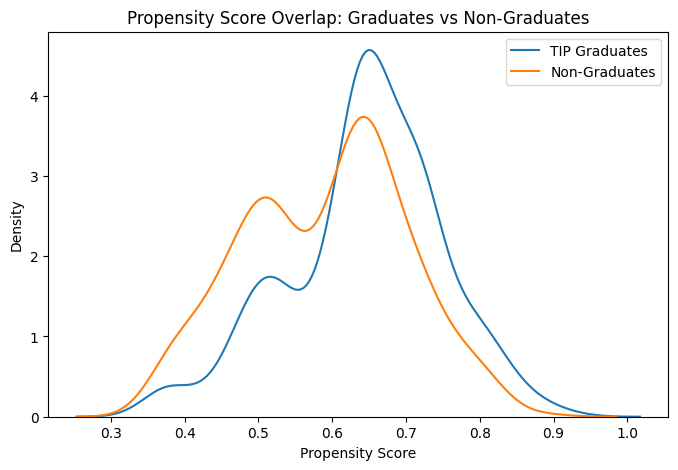


Propensity score summary by treatment:
           count      mean       std       min       25%       50%       75%  \
treatment                                                                      
0          434.0  0.590888  0.109714  0.350858  0.508979  0.608743  0.665524   
1          720.0  0.643910  0.105302  0.338910  0.590522  0.650931  0.715112   

                max  
treatment            
0          0.887895  
1          0.932312  


In [29]:
# 3. Estimate propensity scores and inspect overlap

# Propensity score model uses pre-treatment covariates only
psm_covariates = X_values.drop(columns=['treatment']).copy()

psm_model = LogisticRegression(max_iter=2000, random_state=42)
psm_model.fit(psm_covariates, analysis_df['treatment'])

psm_diagnostics = psm_covariates.copy()
psm_diagnostics['pscore'] = psm_model.predict_proba(psm_covariates)[:, 1]
psm_diagnostics['treatment'] = analysis_df['treatment'].astype(int).values

plt.figure(figsize=(8, 5))
sns.kdeplot(
    psm_diagnostics.loc[psm_diagnostics['treatment'] == 1, 'pscore'],
    label='TIP Graduates'
)
sns.kdeplot(
    psm_diagnostics.loc[psm_diagnostics['treatment'] == 0, 'pscore'],
    label='Non-Graduates'
)
plt.xlabel('Propensity Score')
plt.ylabel('Density')
plt.title('Propensity Score Overlap: Graduates vs Non-Graduates')
plt.legend()
plt.show()

print("\nPropensity score summary by treatment:")
print(psm_diagnostics.groupby('treatment')['pscore'].describe())

In [30]:
# 4. Run naive logistic regression for employment

X_logit = sm.add_constant(X_values.copy())

logit_has_employment = sm.Logit(Y_has_employment, X_logit).fit()
logit_has_employment.summary()



         Current function value: 0.377510
         Iterations: 35


c:\Program Files\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:     employment_outcome   No. Observations:                 1154
Model:                          Logit   Df Residuals:                     1137
Method:                           MLE   Df Model:                           16
Date:                Thu, 02 Apr 2026   Pseudo R-squ.:                  0.4371
Time:                        15:01:55   Log-Likelihood:                -435.65
converged:                      False   LL-Null:                       -773.90
Covariance Type:            nonrobust   LLR p-value:                1.287e-133
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          0.3318      0.376      0.883      0.377      -0.404       1.068
treatment                      0.1598      0.181      0.885      0.376      -0.194       0.514
year_TIP                       1.7752      0.172     10.320      0.000       1.438       2.112
num_sentences_before_start    -0.1146      0.108     -1.061      0.289      -0.326       0.097
num_arrests_before_start       0.0492      0.093      0.531      0.596      -0.132       0.231
any_high_ogs_before_start      0.0289      0.238      0.122      0.903      -0.437       0.495
earnings_1yr_preTIP            0.0001   3.84e-05      3.890      0.000    7.41e-05       0.000
earnings_2yr_preTIP           -0.2506      0.226     -1.110      0.267      -0.693       0.192
job_right_before_tip           0.8660      0.271      3.194      0.001       0.335       1.397
cohort_2022_1                 -2.4889      0.336     -7.397      0.000      -3.148      -1.829
age_band_35+                  -0.2197      0.238     -0.924      0.355      -0.686       0.246
age_band_<=24                  0.0775      0.208      0.373      0.709      -0.330       0.485
age_band_Unknown              -0.2147      0.317     -0.678      0.498      -0.836       0.406
race_Unknown                 -12.9820    232.234     -0.056      0.955    -468.153     442.189
race_White                    -0.0632      0.271     -0.234      0.815      -0.594       0.467
gender_Male                    0.3029      0.311      0.972      0.331      -0.308       0.913
gender_Unknown                -5.2517    944.958     -0.006      0.996   -1857.335    1846.832
==============================================================================================
"""

In [31]:
# 5. Display coefficients and sample counts

logit_has_employment_summary = (
    logit_has_employment.summary2().tables[1].reset_index()
)

print(logit_has_employment_summary[['index', 'Coef.', 'P>|z|']])

print("\nTreatment counts:")
print(analysis_df['treatment'].value_counts(dropna=False))

print("\nStatus counts:")
print(analysis_df['Status'].value_counts(dropna=False))

                         index      Coef.         P>|z|
0                        const   0.331790  3.770676e-01
1                    treatment   0.159800  3.762845e-01
2                     year_TIP   1.775207  5.695345e-25
3   num_sentences_before_start  -0.114624  2.888579e-01
4     num_arrests_before_start   0.049201  5.955053e-01
5    any_high_ogs_before_start   0.028942  9.030767e-01
6          earnings_1yr_preTIP   0.000149  1.003796e-04
7          earnings_2yr_preTIP  -0.250637  2.669412e-01
8         job_right_before_tip   0.866047  1.401539e-03
9                cohort_2022_1  -2.488911  1.388178e-13
10                age_band_35+  -0.219729  3.552529e-01
11               age_band_<=24   0.077529  7.089916e-01
12            age_band_Unknown  -0.214739  4.978821e-01
13                race_Unknown -12.982019  9.554210e-01
14                  race_White  -0.063225  8.152432e-01
15                 gender_Male   0.302892  3.308473e-01
16              gender_Unknown  -5.251725  9.955

# Matching

In [32]:
matching_df = grad_non_grad.copy()

# Keep needed variables
matching_df = matching_df[
    [
        'tip_id',
        'Status',
        'treatment',
        'StartDate',
        'year_TIP',
        'cohort_2022',
        'Age_at_start',
        'age_band',
        'race',
        'gender',
        'census_tract',
        'any_sentence_before_start',
        'num_sentences_before_start',
        'max_ogs_before_start',
        'any_high_ogs_before_start',
        'any_arrest_before_start',
        'num_arrests_before_start',
        'earnings_1yr_preTIP',
        'earnings_2yr_preTIP',
        'job_right_before_tip',
        'employment_outcome',
        'earnings_outcome',
        'offense_outcome',
        'arrest_outcome'
    ]
].copy()

# Clean matching variables
matching_df = matching_df.dropna(subset=['cohort_2022', 'age_band', 'race', 'gender']).copy()

matching_df['cohort_2022'] = matching_df['cohort_2022'].astype(int)
matching_df['race'] = matching_df['race'].astype(str)
matching_df['gender'] = matching_df['gender'].astype(str)

print("matching_df shape:", matching_df.shape)
print("\nTreatment counts:")
print(matching_df['treatment'].value_counts(dropna=False))

print("\nExact-match strata counts:")
print(
    matching_df.groupby(['cohort_2022', 'race', 'gender'])
    .size()
    .reset_index(name='n')
    .sort_values(['cohort_2022', 'race', 'gender'])
)


# Covariates for propensity score model
psm_vars = [
    'year_TIP',  # maybe we want to reconsider this in the future - may be redundant
    'num_sentences_before_start',
    'num_arrests_before_start',
    'any_high_ogs_before_start',
    # 'earnings_1yr_preTIP',
    'earnings_2yr_preTIP',
    'job_right_before_tip'
]

continuous_vars = [
    'year_TIP',
    'num_sentences_before_start',
    'num_arrests_before_start',
    # 'earnings_1yr_preTIP',
    'earnings_2yr_preTIP'
]

matching_df shape: (1047, 24)

Treatment counts:
treatment
1    646
0    401
Name: count, dtype: int64

Exact-match strata counts:
    cohort_2022     race   gender    n
0             0    Black   Female   41
1             0    Black     Male  604
2             0  Unknown     Male    4
3             0  Unknown  Unknown   42
4             0    White   Female    8
5             0    White     Male   72
6             1    Black   Female   46
7             1    Black     Male  192
8             1  Unknown   Female    1
9             1  Unknown     Male    1
10            1  Unknown  Unknown   17
11            1    White   Female    2
12            1    White     Male   17


In [33]:
def nearest_neighbor_match_within_strata_with_psm(
    df,
    exact_vars,
    psm_vars,
    continuous_vars,
    treatment_col='treatment',
    id_col='tip_id',
    caliper=0.20
):
    """
    1:1 nearest-neighbor matching without replacement.

    Step 1: exact match by strata
    Step 2: within each stratum, estimate propensity scores
    Step 3: within each stratum, match on propensity score distance
    """
    matched_rows = []
    pair_id = 1

    # Loop over exact-match strata first
    for strata_values, strata_df in df.groupby(exact_vars, dropna=False):
        strata_df = strata_df.copy()

        treated_df = strata_df[strata_df[treatment_col] == 1].copy()
        control_df = strata_df[strata_df[treatment_col] == 0].copy()

        # Need both treated and control in the stratum
        if len(treated_df) == 0 or len(control_df) == 0:
            continue

        # Build propensity score model within stratum
        psm_covariates = strata_df[psm_vars].copy()

        # Standardize continuous variables within stratum
        scaler = StandardScaler()
        psm_covariates[continuous_vars] = scaler.fit_transform(psm_covariates[continuous_vars])

        # Fit logistic regression for propensity score within stratum
        psm_model = LogisticRegression(max_iter=2000, random_state=42)
        psm_model.fit(psm_covariates, strata_df[treatment_col])

        strata_df['pscore'] = psm_model.predict_proba(psm_covariates)[:, 1]

        treated_df = strata_df[strata_df[treatment_col] == 1].copy()
        control_df = strata_df[strata_df[treatment_col] == 0].copy()

        treated_df = treated_df.sort_values('pscore').reset_index(drop=True)
        control_df = control_df.sort_values('pscore').reset_index(drop=True)

        matched_control_ids = set()

        # Nearest-neighbor matching within this exact stratum
        for _, treated_row in treated_df.iterrows():
            eligible_controls = control_df[
                ~control_df[id_col].isin(matched_control_ids)
            ].copy()

            if len(eligible_controls) == 0:
                continue

            eligible_controls['pscore_diff'] = np.abs(
                eligible_controls['pscore'] - treated_row['pscore']
            )

            eligible_controls = eligible_controls[
                eligible_controls['pscore_diff'] <= caliper
            ].copy()

            if len(eligible_controls) == 0:
                continue

            best_control = eligible_controls.sort_values('pscore_diff').iloc[0]

            treated_out = treated_row.to_dict()
            treated_out['match_pair_id'] = pair_id
            treated_out['match_role'] = 'treated'
            treated_out['matched_to_id'] = best_control[id_col]
            treated_out['match_pscore_diff'] = abs(treated_row['pscore'] - best_control['pscore'])

            control_out = best_control.to_dict()
            control_out['match_pair_id'] = pair_id
            control_out['match_role'] = 'control'
            control_out['matched_to_id'] = treated_row[id_col]
            control_out['match_pscore_diff'] = abs(treated_row['pscore'] - best_control['pscore'])

            matched_rows.append(treated_out)
            matched_rows.append(control_out)

            matched_control_ids.add(best_control[id_col])
            pair_id += 1

    matched_df = pd.DataFrame(matched_rows)
    return matched_df


exact_match_vars = ['cohort_2022', 'race', 'gender']

matched_grad_non_grad = nearest_neighbor_match_within_strata_with_psm(
    df=matching_df,
    exact_vars=exact_match_vars,
    psm_vars=psm_vars,
    continuous_vars=continuous_vars,
    treatment_col='treatment',
    id_col='tip_id',
    caliper=0.20
)

print("matched_grad_non_grad shape:", matched_grad_non_grad.shape)
print("\nMatched pair count:", matched_grad_non_grad['match_pair_id'].nunique())

print("\nMatched treatment counts:")
print(matched_grad_non_grad['treatment'].value_counts(dropna=False))

if 'pscore' in matched_grad_non_grad.columns:
    print("\nMatched propensity score summary:")
    print(matched_grad_non_grad.groupby('treatment')['pscore'].describe())

matched_grad_non_grad shape: (782, 30)

Matched pair count: 391

Matched treatment counts:
treatment
1    391
0    391
Name: count, dtype: int64

Matched propensity score summary:
           count      mean       std       min       25%       50%       75%  \
treatment                                                                      
0          391.0  0.594184  0.081047  0.293914  0.533122  0.601729  0.636665   
1          391.0  0.578586  0.061844  0.293914  0.534599  0.589475  0.618053   

                max  
treatment            
0          0.880961  
1          0.702960  


In [34]:
print("Matched status counts:")
print(matched_grad_non_grad['Status'].value_counts(dropna=False))

print("\nMatched exact strata check:")
print(
    matched_grad_non_grad.groupby(['cohort_2022', 'race', 'gender', 'age_band', 'treatment'])
    .size()
    .reset_index(name='n')
    .sort_values(['cohort_2022', 'race', 'gender', 'age_band', 'treatment'])
)

print("\nAverage propensity score difference within matched pairs:")
print(matched_grad_non_grad[['match_pair_id', 'match_pscore_diff']].drop_duplicates()['match_pscore_diff'].describe())

Matched status counts:
Status
Graduated        391
Non Graduated    391
Name: count, dtype: int64

Matched exact strata check:
    cohort_2022     race   gender age_band  treatment    n
0             0    Black   Female    25-34          0    3
1             0    Black   Female    25-34          1    7
2             0    Black   Female      35+          0    4
3             0    Black   Female      35+          1    4
4             0    Black   Female     <=24          0    8
5             0    Black   Female     <=24          1    4
6             0    Black     Male    25-34          0  112
7             0    Black     Male    25-34          1  137
8             0    Black     Male      35+          0   34
9             0    Black     Male      35+          1   61
10            0    Black     Male     <=24          0  107
11            0    Black     Male     <=24          1   55
12            0  Unknown     Male    25-34          0    1
13            0  Unknown     Male    25-34     

In [35]:
treated_pairs = matched_grad_non_grad[
    matched_grad_non_grad['match_role'] == 'treated'
][
    ['match_pair_id', 'tip_id', 'pscore', 'cohort_2022', 'race', 'gender', 'age_band', 'match_pscore_diff']
].rename(columns={
    'tip_id': 'treated_tip_id',
    'pscore': 'treated_pscore'
})

control_pairs = matched_grad_non_grad[
    matched_grad_non_grad['match_role'] == 'control'
][
    ['match_pair_id', 'tip_id', 'pscore']
].rename(columns={
    'tip_id': 'control_tip_id',
    'pscore': 'control_pscore'
})

matched_pair_summary = treated_pairs.merge(control_pairs, on='match_pair_id', how='inner')

matched_pair_summary.head(20)



,match_pair_id,treated_tip_id,treated_pscore,cohort_2022,race,gender,age_band,match_pscore_diff,control_tip_id,control_pscore
0,1,1419,0.432160,0,Black,Female,25-34,0.004430,1424,0.436591
1,2,996,0.442704,0,Black,Female,<=24,0.003633,1434,0.446337
2,3,198,0.447651,0,Black,Female,35+,0.000000,51,0.447651
3,4,274,0.468510,0,Black,Female,25-34,0.020970,499,0.489480
4,5,1331,0.483324,0,Black,Female,25-34,0.006155,402,0.489480
5,6,536,0.510486,0,Black,Female,<=24,0.000000,601,0.510486
6,7,512,0.510486,0,Black,Female,25-34,0.028906,1423,0.539392
7,8,744,0.531456,0,Black,Female,<=24,0.018307,953,0.549763
8,9,963,0.532403,0,Black,Female,25-34,0.055178,1416,0.587582
9,10,1032,0.536577,0,Black,Female,25-34,0.061526,673,0.598102


In [36]:
matched_grad_non_grad = matched_grad_non_grad.sort_values(
    ['match_pair_id', 'match_role']
).reset_index(drop=True)

print("Final matched analysis file shape:", matched_grad_non_grad.shape)

matched_grad_non_grad.head()



Final matched analysis file shape: (782, 30)


,tip_id,Status,treatment,StartDate,year_TIP,cohort_2022,Age_at_start,age_band,race,gender,...,employment_outcome,earnings_outcome,offense_outcome,arrest_outcome,pscore,match_pair_id,match_role,matched_to_id,match_pscore_diff,pscore_diff
0,1424,Non Graduated,0,2021-09-07,2021,0,42.299385,35+,Black,Female,...,1,36047.518654,0,0,0.436591,1,control,1419,0.004430,0.004430
1,1419,Graduated,1,2021-08-23,2021,0,25.126452,25-34,Black,Female,...,1,132552.463433,0,0,0.432160,1,treated,1424,0.004430,NaN
2,1434,Non Graduated,0,2021-10-18,2021,0,19.707450,<=24,Black,Female,...,1,51346.553331,0,0,0.446337,2,control,996,0.003633,0.003633
3,996,Graduated,1,2019-07-15,2019,0,18.121668,<=24,Black,Female,...,1,60468.596230,0,0,0.442704,2,treated,1434,0.003633,NaN
4,51,Non Graduated,0,2014-02-25,2014,0,25.807245,25-34,Black,Female,...,0,0.000000,0,0,0.447651,3,control,198,0.000000,0.000000


# Matched Sample Diagnostics and Preliminary Outcome Comparisons

Now that we have constructed the matched graduate vs. non-graduate sample, the next step is to evaluate whether the matched sample is sufficiently balanced and to summarize outcome differences before running formal matched regressions.

This section has two goals.

First, we examine **matched sample diagnostics**. We compare the treatment and control groups on key pre-TIP covariates and compute standardized mean differences (SMDs). This helps us assess whether the matching procedure improved comparability between graduates and non-graduates.

Second, we present **simple matched outcome comparisons**. For the matched sample, we compare average employment, earnings, offense, and arrest outcomes between graduates and non-graduates. These comparisons are descriptive and are intended to show the direction and magnitude of differences after matching.

These results are not yet the final adjusted estimates. If residual imbalance remains for some baseline variables, those variables should be controlled for in the next matched regression step.m

In [37]:
matched_analysis = matched_grad_non_grad.copy()

print("Matched sample size:", len(matched_analysis))
print("Matched pair count:", matched_analysis['match_pair_id'].nunique())

print("\nTreatment counts:")
print(matched_analysis['treatment'].value_counts(dropna=False))

print("\nStatus counts:")
print(matched_analysis['Status'].value_counts(dropna=False))

print("\nCohort by treatment:")
print(pd.crosstab(matched_analysis['cohort_2022'], matched_analysis['treatment'], margins=True))

print("\nAge band by treatment:")
print(pd.crosstab(matched_analysis['age_band'], matched_analysis['treatment'], margins=True))

print("\nRace by treatment:")
print(pd.crosstab(matched_analysis['race'], matched_analysis['treatment'], margins=True))

print("\nGender by treatment:")
print(pd.crosstab(matched_analysis['gender'], matched_analysis['treatment'], margins=True))



Matched sample size: 782
Matched pair count: 391

Treatment counts:
treatment
0    391
1    391
Name: count, dtype: int64

Status counts:
Status
Non Graduated    391
Graduated        391
Name: count, dtype: int64

Cohort by treatment:
treatment      0    1  All
cohort_2022               
0            313  313  626
1             78   78  156
All          391  391  782

Age band by treatment:
treatment    0    1  All
age_band                
25-34      163  194  357
35+         51   92  143
<=24       177  105  282
All        391  391  782

Race by treatment:
treatment    0    1  All
race                    
Black      335  335  670
Unknown     21   21   42
White       35   35   70
All        391  391  782

Gender by treatment:
treatment    0    1  All
gender                  
Female      27   27   54
Male       344  344  688
Unknown     20   20   40
All        391  391  782


In [38]:
matched_analysis.columns



Index(['tip_id', 'Status', 'treatment', 'StartDate', 'year_TIP', 'cohort_2022',
       'Age_at_start', 'age_band', 'race', 'gender', 'census_tract',
       'any_sentence_before_start', 'num_sentences_before_start',
       'max_ogs_before_start', 'any_high_ogs_before_start',
       'any_arrest_before_start', 'num_arrests_before_start',
       'earnings_1yr_preTIP', 'earnings_2yr_preTIP', 'job_right_before_tip',
       'employment_outcome', 'earnings_outcome', 'offense_outcome',
       'arrest_outcome', 'pscore', 'match_pair_id', 'match_role',
       'matched_to_id', 'match_pscore_diff', 'pscore_diff'],
      dtype='object')

In [39]:
balance_vars = [
    'year_TIP',
    'num_sentences_before_start',
    'max_ogs_before_start',
    'any_high_ogs_before_start',
    'num_arrests_before_start',
    'earnings_1yr_preTIP',
    'earnings_2yr_preTIP',
    'job_right_before_tip'
    
]

balance_table = matched_analysis.groupby('treatment')[balance_vars].mean().T
balance_table.columns = ['matched_control_mean', 'matched_treated_mean']
balance_table['difference'] = (
    balance_table['matched_treated_mean'] - balance_table['matched_control_mean']
)

balance_table

,matched_control_mean,matched_treated_mean,difference
year_TIP,2018.342711,2018.207161,-0.135550
num_sentences_before_start,2.043478,1.511509,-0.531969
max_ogs_before_start,2.659847,2.386189,-0.273657
any_high_ogs_before_start,0.265985,0.255754,-0.010230
num_arrests_before_start,1.168798,1.163683,-0.005115
earnings_1yr_preTIP,4967.689636,5749.690109,782.000473
earnings_2yr_preTIP,3761.310267,3468.880571,-292.429696
job_right_before_tip,0.447570,0.478261,0.030691


In [40]:
def standardized_mean_diff(df, treatment_col, var):
    treated = df[df[treatment_col] == 1][var].dropna()
    control = df[df[treatment_col] == 0][var].dropna()

    mean_t = treated.mean()
    mean_c = control.mean()

    var_t = treated.var()
    var_c = control.var()

    pooled_sd = np.sqrt((var_t + var_c) / 2)

    if pooled_sd == 0:
        return 0

    return (mean_t - mean_c) / pooled_sd

smd_results = []
for var in balance_vars:
    smd_results.append({
        'variable': var,
        'SMD': standardized_mean_diff(matched_analysis, 'treatment', var)
    })

smd_table = pd.DataFrame(smd_results).sort_values('SMD', key=lambda x: x.abs(), ascending=False)
smd_table

,variable,SMD
1,num_sentences_before_start,-0.160041
5,earnings_1yr_preTIP,0.075390
2,max_ogs_before_start,-0.073136
7,job_right_before_tip,0.061501
0,year_TIP,-0.039247
6,earnings_2yr_preTIP,-0.034395
3,any_high_ogs_before_start,-0.023269
4,num_arrests_before_start,-0.001729


Matched pair propensity-score difference summary:
count    391.000000
mean       0.027508
std        0.033986
min        0.000000
25%        0.007658
50%        0.019012
75%        0.027898
max        0.185815
Name: match_pscore_diff, dtype: float64


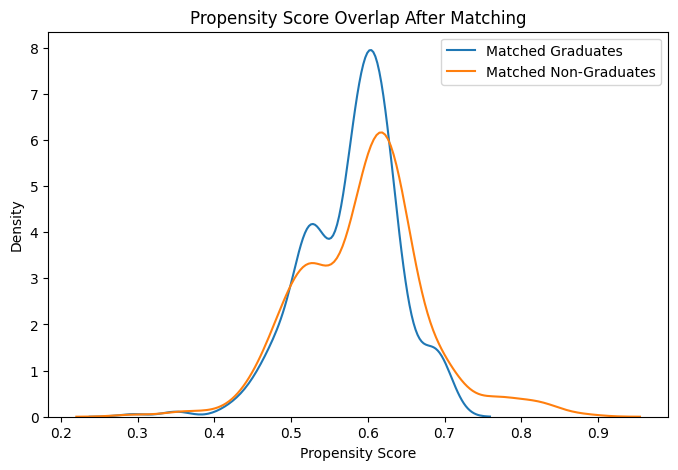

In [41]:


print("Matched pair propensity-score difference summary:")
print(
    matched_analysis[['match_pair_id', 'match_pscore_diff']]
    .drop_duplicates()['match_pscore_diff']
    .describe()
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.kdeplot(
    matched_analysis.loc[matched_analysis['treatment'] == 1, 'pscore'],
    label='Matched Graduates'
)
sns.kdeplot(
    matched_analysis.loc[matched_analysis['treatment'] == 0, 'pscore'],
    label='Matched Non-Graduates'
)
plt.xlabel('Propensity Score')
plt.ylabel('Density')
plt.title('Propensity Score Overlap After Matching')
plt.legend()
plt.show()



In [42]:
outcome_vars = [
    'employment_outcome',
    'earnings_outcome',
    'offense_outcome',
    'arrest_outcome'
]

matched_outcome_table = matched_analysis.groupby('treatment')[outcome_vars].mean().T
matched_outcome_table.columns = ['matched_control_mean', 'matched_treated_mean']
matched_outcome_table['difference'] = (
    matched_outcome_table['matched_treated_mean'] - matched_outcome_table['matched_control_mean']
)

matched_outcome_table

,matched_control_mean,matched_treated_mean,difference
employment_outcome,0.618926,0.613811,-0.005115
earnings_outcome,10165.194825,10914.575827,749.381003
offense_outcome,0.071611,0.092072,0.020460
arrest_outcome,0.107417,0.112532,0.005115


In [43]:
##tip_demos = tip_demos.set_index('tip_id').to_dict(orient='index')
all_tip_data_dict = all_tip_data.set_index('tip_id').to_dict(orient='index')

tip_sentencing = tip_sentencing.dropna(subset=['DOS'])
tip_sentencing['year'] = tip_sentencing['DOS'].dt.year.astype(int)

all_tip_data['year'] = all_tip_data['StartDate'].dt.year.astype(int)

In [44]:
def participated_tip(tip_id, year):
    if len(all_tip_data[(all_tip_data['tip_id'] == tip_id) & (all_tip_data['year'] <= year)]) > 0:
        return 1
    else:
        return 0
    
def graduated_tip(tip_id, year):
    if len(all_tip_data[(all_tip_data['tip_id'] == tip_id) & (all_tip_data['year'] <= year) & (all_tip_data['Status'] == 'Graduated')]) > 0:
        return 1
    else:
        return 0

def employed_full_year(tip_id, year):
    earnings = tip_earnings[(tip_earnings['tip_id'] == tip_id) & (tip_earnings['year'] == year)]
    if len(earnings) == 0:
        return 0
    else:
        if earnings['year_quarter_dt'].nunique() == 4:
            return 1
        else:
            return 0
        
def employed_partial_year(tip_id, year):
    earnings = tip_earnings[(tip_earnings['tip_id'] == tip_id) & (tip_earnings['year'] == year)]
    if len(earnings) == 0:
        return 0
    else:
        if earnings['year_quarter_dt'].nunique() > 0:
            return 1
        else:
            return 0
        
def earnings_full_year(tip_id, year):
    earnings = tip_earnings[(tip_earnings['tip_id'] == tip_id) & (tip_earnings['year'] == year)]
    return earnings['adjusted_earnings'].sum() if len(earnings) > 0 else 0

def offense_count_full_year(tip_id, year):
    offenses = tip_sentencing[(tip_sentencing['tip_id'] == tip_id) & (tip_sentencing['year'] == year)]
    if len(offenses) > 0:
        return len(offenses)
    else:
        return 0
    
def has_offense_full_year(tip_id, year):
    offenses = tip_sentencing[(tip_sentencing['tip_id'] == tip_id) & (tip_sentencing['year'] == year)]
    if len(offenses) > 0:
        return 1
    else:
        return 0

# Age subgroup analysis

In [45]:
panel_df_age = []

for tip_id in matched_grad_non_grad.tip_id.unique():
    for year in range(2017, 2025):
        panel_df_age.append({
            'tip_id': tip_id,
            'year': year,
            'age_band': all_tip_data_dict[tip_id]['age_band'] if tip_id in all_tip_data_dict else 'Unknown',
            'StartDate' : all_tip_data_dict[tip_id]['StartDate'] if tip_id in all_tip_data_dict else 'Unknown',
            'EndDate' : all_tip_data_dict[tip_id]['EndDate'] if tip_id in all_tip_data_dict else 'Unknown',
            'Status' : all_tip_data_dict[tip_id]['Status'] if tip_id in all_tip_data_dict else 'Unknown',
            'cohort_2022' : all_tip_data_dict[tip_id]['cohort_2022'] if tip_id in all_tip_data_dict else 'Unknown',
            'race': tip_demos[tip_id]['race'] if tip_id in tip_demos else 'Unknown',
            'gender': tip_demos[tip_id]['gender'] if tip_id in tip_demos else 'Unknown',
            'census_tract': int(tip_demos[tip_id]['census_tract']) if tip_id in tip_demos and not pd.isnull(tip_demos[tip_id]['census_tract']) else "Unknown",
            'participated_tip': participated_tip(tip_id, year),
            'graduated_tip': graduated_tip(tip_id, year),
            'employed_full_year': employed_full_year(tip_id, year),
            'employed_partial_year': employed_partial_year(tip_id, year),
            'earnings_full_year': earnings_full_year(tip_id, year),
            'offense_count_year': offense_count_full_year(tip_id, year),
            'has_offense_year': has_offense_full_year(tip_id, year)
        })

panel_df_age = pd.DataFrame(panel_df_age)

# make sure EndDate is datetime
panel_df_age['EndDate'] = pd.to_datetime(panel_df_age['EndDate'], errors='coerce')

# first apply the rough EndDate cutoff
cutoff = pd.Timestamp('2018-01-01', tz='UTC')
panel_df_age = panel_df_age[panel_df_age['EndDate'] >= cutoff].copy()

# then ensure each person has at least one pre-TIP period in the panel
valid_tip_ids = (
    panel_df_age.groupby('tip_id')['participated_tip']
    .apply(lambda x: (x == 0).any())
)

valid_tip_ids = valid_tip_ids[valid_tip_ids].index

panel_df_age = panel_df_age[panel_df_age['tip_id'].isin(valid_tip_ids)].copy()

In [46]:
panel_df_age.columns

Index(['tip_id', 'year', 'age_band', 'StartDate', 'EndDate', 'Status',
       'cohort_2022', 'race', 'gender', 'census_tract', 'participated_tip',
       'graduated_tip', 'employed_full_year', 'employed_partial_year',
       'earnings_full_year', 'offense_count_year', 'has_offense_year'],
      dtype='object')

In [47]:
panel_df_age['age_band'].value_counts()

age_band
<=24     1608
25-34    1560
35+       584
Name: count, dtype: int64

In [48]:
panel_df_age.columns

Index(['tip_id', 'year', 'age_band', 'StartDate', 'EndDate', 'Status',
       'cohort_2022', 'race', 'gender', 'census_tract', 'participated_tip',
       'graduated_tip', 'employed_full_year', 'employed_partial_year',
       'earnings_full_year', 'offense_count_year', 'has_offense_year'],
      dtype='object')

In [49]:
# Copy panel data
fe_data_age = panel_df_age.copy()

# Keep needed columns
fe_data_age = fe_data_age[
    [
        'tip_id',
        'year',
        'cohort_2022',
        'age_band',
        'graduated_tip',
        'has_offense_year',
        'earnings_full_year'
    ]
].copy()

# Log earnings outcome
fe_data_age['log_earnings'] = np.log(fe_data_age['earnings_full_year'] + 1)

# Clean age_band
fe_data_age['age_band'] = fe_data_age['age_band'].astype(str)

fe_data_age['cohortXgraduated'] = fe_data_age['cohort_2022'] * fe_data_age['graduated_tip']

# Create age-band dummies
# Use <=24 as reference group
fe_data_age['age_24_minus'] = (fe_data_age['age_band'] == '<=24').astype(int)
fe_data_age['age_25_34'] = (fe_data_age['age_band'] == '25-34').astype(int)
fe_data_age['age_35_plus'] = (fe_data_age['age_band'] == '35+').astype(int)

fe_data_age['gradXage_24_minus'] = fe_data_age['graduated_tip'] * fe_data_age['age_24_minus']
fe_data_age['gradXage_25_34'] = fe_data_age['graduated_tip'] * fe_data_age['age_25_34']
fe_data_age['gradXage_35_plus'] = fe_data_age['graduated_tip'] * fe_data_age['age_35_plus']

fe_data_age['cohortXage_24_minus'] = fe_data_age['cohort_2022'] * fe_data_age['age_24_minus']
fe_data_age['cohortXage_25_34'] = fe_data_age['cohort_2022'] * fe_data_age['age_25_34']
fe_data_age['cohortXage_35_plus'] = fe_data_age['cohort_2022'] * fe_data_age['age_35_plus']

fe_data_age['cohortXage_24_minus'] = fe_data_age['cohortXage_24_minus'].astype('category')
fe_data_age['cohortXage_25_34'] = fe_data_age['cohortXage_25_34'].astype('category')
fe_data_age['cohortXage_35_plus'] = fe_data_age['cohortXage_35_plus'].astype('category')

fe_data_age['gradXage_24_minus'] = fe_data_age['gradXage_24_minus'].astype('category')
fe_data_age['gradXage_25_34'] = fe_data_age['gradXage_25_34'].astype('category')
fe_data_age['gradXage_35_plus'] = fe_data_age['gradXage_35_plus'].astype('category')

# Set panel index
fe_data_age = fe_data_age.set_index(['tip_id', 'year'])

fe_data_age.head()


cohort_2022 age_band  graduated_tip  has_offense_year  \
tip_id year                                                          
1424   2017          0.0      35+              0                 0   
       2018          0.0      35+              0                 0   
       2019          0.0      35+              0                 0   
       2020          0.0      35+              0                 0   
       2021          0.0      35+              0                 0   

             earnings_full_year  log_earnings  cohortXgraduated  age_24_minus  \
tip_id year                                                                     
1424   2017         8701.881856      9.071409               0.0             0   
       2018         6141.889560      8.723051               0.0             0   
       2019        25436.811923     10.143992               0.0             0   
       2020        49426.242625     10.808257               0.0             0   
       2021        48816.169898     10.795837               0.0             0   

             age_25_34  age_35_plus gradXage_24_minus gradXage_25_34  \
tip_id year                                                            
1424   2017          0            1                 0              0   
       2018          0            1                 0              0   
       2019          0            1                 0              0   
       2020          0            1                 0              0   
       2021          0            1                 0              0   

            gradXage_35_plus cohortXage_24_minus cohortXage_25_34  \
tip_id year                                                         
1424   2017                0                 0.0              0.0   
       2018                0                 0.0              0.0   
       2019                0                 0.0              0.0   
       2020                0                 0.0              0.0   
       2021                0                 0.0              0.0   

            cohortXage_35_plus  
tip_id year                     
1424   2017                0.0  
       2018                0.0  
       2019                0.0  
       2020                0.0  
       2021                0.0

In [57]:
# FE model
model_fe_age_interact = PanelOLS.from_formula(
    formula="""
    log_earnings ~ 1 
    + graduated_tip 
    + has_offense_year 
    + cohortXage_24_minus
    + EntityEffects 
    + TimeEffects
    """,
    data=fe_data_age, 
    check_rank=False
)

results_fe_age_interact = model_fe_age_interact.fit(
    cov_type='clustered',
    cluster_entity=True,
    cluster_time=True
)

print(results_fe_age_interact.summary)

AbsorbingEffectError: 
The model cannot be estimated. The included effects have fully absorbed
one or more of the variables. This occurs when one or more of the dependent
variable is perfectly explained using the effects included in the model.

The following variables or variable combinations have been fully absorbed
or have become perfectly collinear after effects are removed:

          Intercept, graduated_tip, has_offense_year, cohortXage_24_minus[T.1.0]

Set drop_absorbed=True to automatically drop absorbed variables.


In [54]:
import math
math.log(0.5660)

-0.5691612007789542